# DEMA & TEMA -- are double/triple-smoothed moving averages worth it?
### The 'less-lag' moving averages, raced against a plain SMA, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Worth_it%3F: Busted](https://img.shields.io/badge/Worth_it%3F-Busted-8b949e?style=flat-square)

Every charting package ships them: **DEMA** (double exponential moving average) and **TEMA** (triple). The pitch is irresistible -- a normal moving average *lags* price, so your trend signals are always late; DEMA and TEMA use a clever algebra trick to **cancel most of the lag** while staying smooth. 'Same signal, earlier -- so you make more money.' This notebook asks the only question that matters: when you turn them into an actual trading rule, do they beat a boring plain moving average?

> **This is the plain-language layer.** Want the Sharpe race, the HAC *t*-stats, the permutation null and the cost sweep? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dema_tema import data, strategy as st

ASOF = "2026-05-31"          # partial June dropped from the stamped run
KINDS = ["sma", "ema", "dema", "tema"]
COLORS = {"sma": GREY, "ema": "#5b8def", "dema": AMBER, "tema": RED}

def spy():
    b = data.load_real("SPY", fetch=False)
    return b[b.index <= ASOF]

HAVE_REAL = data.have_real("SPY")
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does TEMA beat a plain SMA? | **No.** On 21 years of SPY the SMA trend rule nets a Sharpe of **0.54**; TEMA nets **0.24** -- *worse*. |
| Does any of them beat just holding SPY? | **No.** Buy-and-hold nets **0.65**; every MA rule lands below it. |
| What did the extra 'responsiveness' buy you? | **More trading.** TEMA turns over **~39x/yr** vs **~17x** for the SMA -- it reacts to noise, gets whipsawed, and pays the costs. |
| Could you trade it? | **Mirage.** It loses to the simpler tool *and* to doing nothing, before you even get to costs. |

> The lag-cancellation is real maths. But less lag means **more reaction to noise** -- and on a daily stock tape that trades you in and out for nothing.

## 1 - The claim

> *"A simple moving average lags price by half its window -- by the time it turns, the move is half over. DEMA (Mulloy, 1994) and TEMA fix that: 2x or 3x EMAs combined so the lag mostly cancels. You get the smoothness of a long average with the responsiveness of a short one -- earlier entries, earlier exits, more profit."*

It is genuinely clever. ``DEMA = 2*EMA - EMA(EMA)`` and ``TEMA = 3*EMA - 3*EMA(EMA) + EMA(EMA(EMA))`` really do cut the phase lag of the filter. The believer's bet is that *less lag = better trend timing = more money*.

## 2 - So what?

If true, it would be a free upgrade: swap your 50-day SMA for a 50-day TEMA in any trend-following rule and pick up return for nothing. Millions of retail charts default to these lines. If it's *false* -- if the extra responsiveness just buys you whipsaws -- then a generation of traders has been paying more in costs to do slightly worse than the plain average they were trying to improve on.

## 3 - How would we even know?

Two rules keep us honest:

1. **Same rule, swap only the line.** Be **long when the close is above its moving average, flat otherwise** -- identical logic for SMA, EMA, DEMA and TEMA at the same 50-day window. The *only* thing that changes is which line we use. We read the signal at today's close and earn *tomorrow's* return (one honest lag), and we charge realistic costs on every switch.
2. **Race the right benchmarks.** Not just each other -- against **buy-and-hold** (does any trend rule even help?) and against the **plain SMA** (does the 'less lag' line beat the boring one it claims to improve?).

**The mirage line:** if TEMA/DEMA don't clear the SMA *and* don't clear buy-and-hold on a net, excess-of-cash Sharpe -- with no positive HAC *t* on the outperformance -- the 'worth it' claim is busted. We run it on **21 years of daily SPY** (2005-2026).

## 4 - The teardown -- let's actually look

**First, the lines themselves.** Here are the four 50-day moving averages on a slice of SPY. DEMA and TEMA do hug price more tightly -- the lag really is smaller.

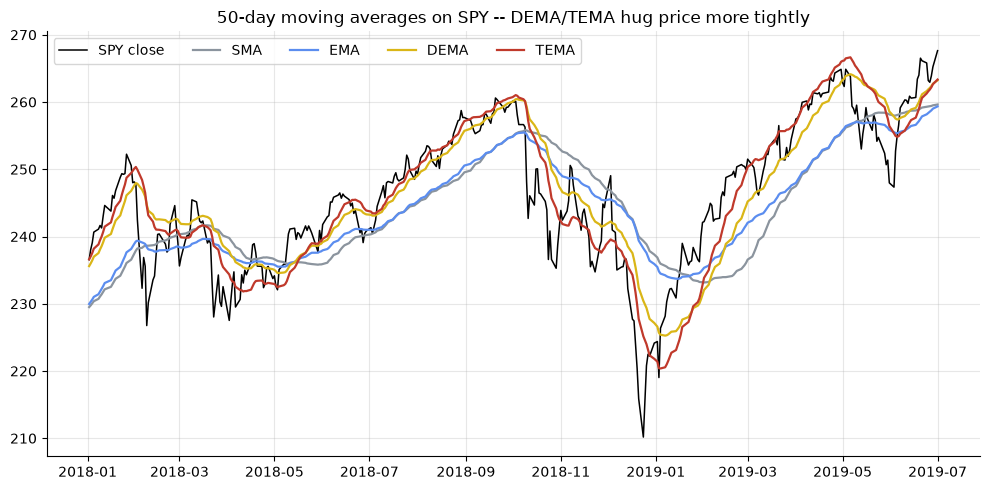

Less lag is visible -- TEMA turns soonest. The question is whether that pays.


In [2]:
b = spy()
win = b.loc['2018-01-01':'2019-07-01']
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(win.index, win['close'], color='k', lw=1.1, label='SPY close')
for k in KINDS:
    ma = st.moving_average(b['close'], k, 50).loc[win.index]
    ax.plot(win.index, ma, color=COLORS[k], lw=1.6, label=k.upper())
ax.set_title('50-day moving averages on SPY -- DEMA/TEMA hug price more tightly')
ax.legend(ncol=5); plt.tight_layout(); plt.show()
print('Less lag is visible -- TEMA turns soonest. The question is whether that pays.')

They turn sooner -- exactly as advertised. Now the only test that matters: **turn each line into the same long/flat rule and see who makes money, net of costs.**

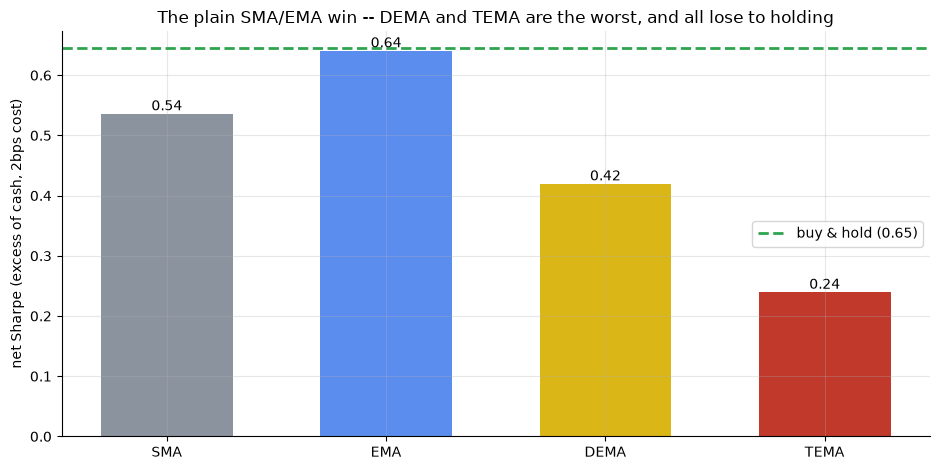

      sharpe_net  sharpe_minus_bh  turnover_per_yr
kind                                              
sma        0.536           -0.109           16.894
ema        0.641           -0.004           18.204
dema       0.420           -0.225           34.208
tema       0.240           -0.405           38.888


In [3]:
res = st.run_experiment(b, n=50, cost_bps=2.0, n_draws=1)
tab = res['table']
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ks = KINDS
vals = [tab.loc[k,'sharpe_net'] for k in ks]
bars = ax.bar([k.upper() for k in ks], vals, color=[COLORS[k] for k in ks], width=.6)
ax.axhline(res['sharpe_bh'], ls='--', c=GREEN, lw=2, label=f"buy & hold ({res['sharpe_bh']:.2f})")
ax.set_ylabel('net Sharpe (excess of cash, 2bps cost)')
ax.set_title('The plain SMA/EMA win -- DEMA and TEMA are the worst, and all lose to holding')
for bb, v in zip(bars, vals):
    ax.annotate(f'{v:.2f}', (bb.get_x()+bb.get_width()/2, v), ha='center', va='bottom', fontsize=10)
ax.legend(); plt.tight_layout(); plt.show()
print(tab[['sharpe_net','sharpe_minus_bh','turnover_per_yr']].round(3).to_string())

The 'improved' lines are the **worst** performers. TEMA nets a Sharpe of **0.24**, DEMA **0.42** -- below the plain SMA's **0.54** and the EMA's **0.64**, and all of them below just **holding SPY** (0.65). The less-lag lines bought you *less* money.

**Why?** Because less lag cuts both ways. Look at how much each rule trades.

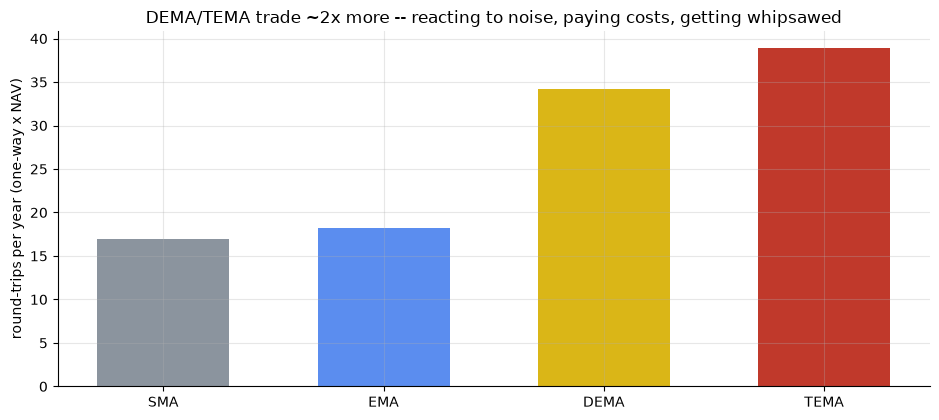

TEMA turnover 39/yr vs SMA 17/yr -- twice the friction for a worse result.


In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4.3))
turns = [tab.loc[k,'turnover_per_yr'] for k in KINDS]
ax.bar([k.upper() for k in KINDS], turns, color=[COLORS[k] for k in KINDS], width=.6)
ax.set_ylabel('round-trips per year (one-way x NAV)')
ax.set_title('DEMA/TEMA trade ~2x more -- reacting to noise, paying costs, getting whipsawed')
plt.tight_layout(); plt.show()
print('TEMA turnover %.0f/yr vs SMA %.0f/yr -- twice the friction for a worse result.'
      % (tab.loc['tema','turnover_per_yr'], tab.loc['sma','turnover_per_yr']))

There it is. The extra 'responsiveness' is responsiveness **to noise**. TEMA flips in and out roughly twice as often as the SMA, eating costs and selling into every wiggle. The lag the SMA carries is partly a *feature* -- it ignores the noise that DEMA/TEMA chase.

## 5 - The verdict

- **Signal -- None.** No MA rule beats buy-and-hold; the outperformance HAC *t* is **negative** for all of them (TEMA *t* = -3.5). The 'less-lag' lines clear no bar at all.
- **Tradability -- Mirage.** DEMA/TEMA lose to the simpler SMA *and* to doing nothing, while trading twice as much. There is nothing to deploy.
- **'Worth it?' -- Busted.** TEMA nets **0.24** vs the SMA's **0.54**. The lag-cancellation is real; the edge it was supposed to buy is not.

## 6 - Could you actually trade it?

It is already behind before costs even bite -- but costs make it worse faster, because it trades more.

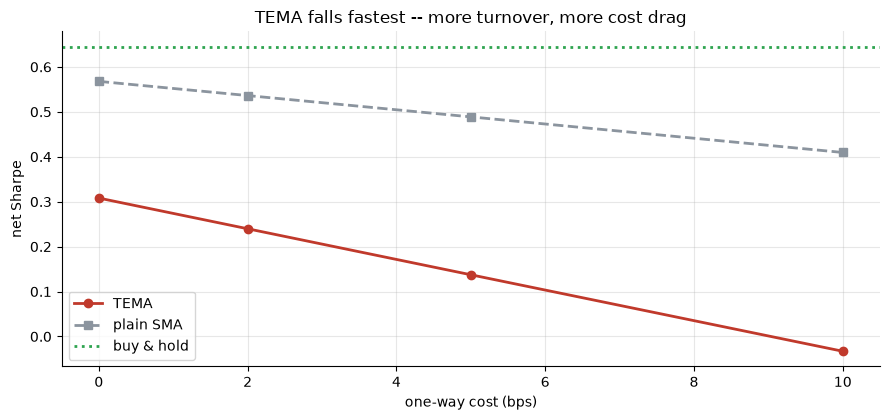

At 10 bps one-way TEMA goes negative; the SMA still clears it -- but neither beats holding.


In [5]:
costs = [0.0, 2.0, 5.0, 10.0]
tema = [st.backtest(b,'tema',50,c)['sharpe_net'] for c in costs]
sma  = [st.backtest(b,'sma', 50,c)['sharpe_net'] for c in costs]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, tema, 'o-', c=RED, lw=2, label='TEMA')
ax.plot(costs, sma, 's--', c=GREY, lw=2, label='plain SMA')
ax.axhline(res['sharpe_bh'], ls=':', c=GREEN, lw=2, label='buy & hold')
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title('TEMA falls fastest -- more turnover, more cost drag'); ax.legend()
plt.tight_layout(); plt.show()
print('At 10 bps one-way TEMA goes negative; the SMA still clears it -- but neither beats holding.')

TEMA's higher turnover means costs erode it fastest -- it crosses zero by ~10 bps while the SMA limps on. But the headline isn't the cost slope; it's that **the gap was already there at zero cost**. This is a Mirage you don't even need costs to see.

## 7 - Going further

- **The positive control (in the quants notebook).** On a synthetic tape with a *planted* trend, the SMA harvests it for a Sharpe up to ~4 while TEMA whipsaws to *negative* -- proving the harness can see an edge, and that DEMA/TEMA are a liability even when there is a real trend to catch.
- **A crossover version.** Instead of price-vs-MA, try a fast/slow DEMA crossover. The responsiveness story predicts it should help; we'd bet it whipsaws harder.
- **Compare with the desk's other MA studies** -- [Bollinger-Reversion](../../104-bollinger-reversion/) (bands vs a random buy) and the golden-cross family. Same lesson recurs: the *line* is rarely the edge.

*Think DEMA/TEMA earn their keep somewhere -- a faster window, a different asset, a crossover? Fork this, and show a net, excess-of-cash Sharpe that beats the plain SMA with a HAC t above 2. That's the bar.*